# Inferring intracellular signaling models with CellNOptDAG

Many signaling experiments follow the same design: stimulate a receptor or inhibit a signaling protein, wait until a chosen endpoint, and measure a panel of phosphoproteins or reporters. Each experimental condition is therefore a **snapshot of the cellular response to an intervention**.

This method is built around one question:

> **What is the smallest connected feed-forward signaling logic sufficient to explain the observed endpoint responses across all interventions?**

A prior-knowledge network (PKN) supplies the candidate biology. It collects signaling interactions reported in the literature or databases and is deliberately inclusive: it may contain alternative routes, AND gates, inhibitory effects, and feedback loops. `CellNOptDAG` searches this network for a small Boolean signaling model that answers the question above across the complete experiment.

Proteins are represented as inactive (`0`) or active (`1`), and the same pathway structure is used in every condition. The interventions change which parts of that pathway can respond. This is a simplified model of intracellular signal transmission—not a reconstruction of every molecular event between stimulation and measurement.

The worked example develops the answer in three steps:

1. identify which candidate signaling reactions are needed;
2. examine how the predicted pathway response changes after each stimulation or inhibition;
3. compare the predicted activities with the measured readouts.

The main workflow explains these steps visually. The final **Under the hood** section connects the biological intuition to the Boolean and optimization formulation.

## One signaling model, several perturbation conditions

CellNOpt learns one pathway diagram from the complete experiment. What happens on that diagram changes from one condition to another.

| Part of the experiment | Biological meaning | Shared across conditions? |
|---|---|---|
| Selected reactions | The signaling interactions retained in the inferred pathway | Yes |
| Stimuli and inhibitors | Which proteins are experimentally forced on or off | No |
| Predicted protein activity | The model's active/inactive response after each intervention | No |
| Active reactions | The retained interactions through which signal can pass in that condition | No |
| Measured readouts | The observed endpoint response used to evaluate the prediction | No |

A reaction may therefore belong to the inferred pathway but remain inactive in a particular condition. For example, an `A → X` reaction can be part of the shared model even when `A` was not stimulated in one experiment.

CORNETO also checks that the retained pathway connects experimental interventions to measured responses. That computational check is explained later; it should not be interpreted as a measured biochemical flux.

## Relationship to CellNOptR

[CellNOptR](https://doi.org/10.1186/1752-0509-6-133) established the idea of training logic models of intracellular signaling against perturbation data. It can iteratively propagate Boolean states toward a steady state and can represent successive pseudo-steady states when several experimental times are available.

This guide addresses the simpler case of one response snapshot per intervention. It retains the CellNOpt ideas of selecting reactions, evaluating Boolean responses in every condition, and balancing data fit against model size. CORNETO adds two restrictions for this endpoint setting: the selected model must be acyclic, and every selected reaction must belong to a connected route from an intervention to a readout. These additions are summarized in **Under the hood**.

## Example: perturbations and two signaling readouts

We use abstract labels so that the logic is easy to follow. `A`, `C`, and `D` play the role of experimentally controlled upstream signals; `B`, `X`, and `W` are intracellular signaling proteins; and `Y` and `Z` are measured downstream responses.

The candidate network includes several plausible mechanisms:

- `D → B`, so activating `D` can indirectly block `A AND NOT B → X`;
- a branch from `X` toward both readouts;
- `W AND C → Z`, representing a response that needs two signals simultaneously;
- alternative ways to activate `Y` through `X`, `C`, or the absence of `D`.

The PKN also contains shortcuts and feedback interactions. They remain legitimate biological hypotheses. The question is whether the snapshot experiment contains enough information to retain them in the fitted endpoint model.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

import corneto as cn
from corneto.methods.signaling import (
    CellNOptDAG,
    plot_cellnopt_fit,
    plot_cellnopt_model,
)

### Define the prior-knowledge network

Positive interactions use sign `+1`; inhibitory interactions use sign `−1`. The temporary nodes `AND1` and `AND2` are the usual SIF representation of two combinatorial signaling rules:

- `A AND NOT B → X`: `A` must be active while `B` must be inactive;
- `W AND C → Z`: both `W` and `C` must be active.

CORNETO treats every complete AND rule as one candidate reaction. The network also includes direct routes to `Z` and the feedback candidates `Y → Z → X` and `Z → W → Z`. Thus the PKN contains cycles even though the fitted endpoint model will not.

In [2]:
pkn_edges = [
    ("A", 1, "AND1"),
    ("B", -1, "AND1"),
    ("AND1", 1, "X"),
    ("D", 1, "B"),
    ("X", 1, "Y"),
    ("X", 1, "W"),
    ("W", 1, "AND2"),
    ("C", 1, "AND2"),
    ("AND2", 1, "Z"),
    ("C", 1, "Y"),
    ("D", -1, "Y"),
    ("W", 1, "Z"),
    ("C", 1, "Z"),
    ("Y", 1, "Z"),
    ("Z", 1, "X"),
    ("Z", -1, "W"),
]
pkn = cn.Graph.from_tuples(pkn_edges)

pd.DataFrame(pkn_edges, columns=["source", "sign", "target"])

,source,sign,target
0,A,1,AND1
1,B,-1,AND1
2,AND1,1,X
3,D,1,B
4,X,1,Y
5,X,1,W
6,W,1,AND2
7,C,1,AND2
8,AND2,1,Z
9,C,1,Y


### Define the perturbation experiment

Each row below corresponds to one experimental condition. It records what was done to the cells and what was measured afterward:

- **input:** `1` forces an upstream signal on and `0` keeps it off, representing stimulus present or absent in this simplified experiment;
- **inhibit:** `1` applies an inhibitor and forces its target off;
- **readout:** the observed activity at the endpoint.

`Y` and `Z` are the only measured responses. Interventions target the upstream or internal signaling proteins `A–D` and `W`, so the roles of experimental cue and downstream readout remain distinct. The interpretation column is a short label for the reader and is not used by the model.

The informative part of the design is the contrast between rows. `C1` and `C2` receive the same upstream inputs, but only `C1` inhibits `B`; their different `Y` responses test the route `D → B` followed by the first AND gate. `C3` and `C4` test whether `C` alone is sufficient for `Z`, or whether `W` is also required. `C4` and `C6` have the same inputs, but inhibiting `W` in `C6` turns `Z` off while leaving `Y` active, directly testing the `W AND C → Z` branch.

In [3]:
inputs = {
    "C1": {"A": 1, "C": 0, "D": 1},
    "C2": {"A": 1, "C": 0, "D": 1},
    "C3": {"A": 0, "C": 1, "D": 1},
    "C4": {"A": 1, "C": 1, "D": 0},
    "C5": {"A": 0, "C": 0, "D": 0},
    "C6": {"A": 1, "C": 1, "D": 0},
}
measurements = {
    "C1": {"Y": 1, "Z": 0},
    "C2": {"Y": 0, "Z": 0},
    "C3": {"Y": 1, "Z": 0},
    "C4": {"Y": 1, "Z": 1},
    "C5": {"Y": 1, "Z": 0},
    "C6": {"Y": 1, "Z": 0},
}
inhibitors = {
    "C1": {"B": 1},
    "C2": {},
    "C3": {},
    "C4": {},
    "C5": {},
    "C6": {"W": 1},
}
behavior = {
    "C1": "B inhibition enables AND1",
    "C2": "D activates B and blocks AND1",
    "C3": "C alone",
    "C4": "AND2 enabled",
    "C5": "negative-literal route",
    "C6": "W inhibited; Z lost",
}

In [4]:
experiment_table = pd.DataFrame(index=inputs)
experiment_table.index.name = "condition"
experiment_table["interpretation"] = pd.Series(behavior)
for species in ["A", "C", "D"]:
    experiment_table[f"input {species}"] = [inputs[name][species] for name in inputs]
for species in ["B", "W"]:
    experiment_table[f"inhibit {species}"] = [inhibitors[name].get(species, 0) for name in inputs]
for species in ["Y", "Z"]:
    experiment_table[f"readout {species}"] = [measurements[name][species] for name in inputs]

experiment_table

,interpretation,input A,input C,input D,inhibit B,inhibit W,readout Y,readout Z
condition,,,,,,,,
C1,B inhibition enables AND1,1,0,1,1,0,1,0
C2,D activates B and blocks AND1,1,0,1,0,0,0,0
C3,C alone,0,1,1,0,0,1,0
C4,AND2 enabled,1,1,0,0,0,1,1
C5,negative-literal route,0,0,0,0,0,1,0
C6,W inhibited; Z lost,1,1,0,0,1,1,0


## Fit one pathway to the complete experiment

All six conditions are fitted together because they are assumed to probe the same underlying signaling network. The model first tries to reproduce the measured `Y` and `Z` responses. Among similarly fitting explanations, it prefers the one using fewer reactions.

`lambda_reg` controls this preference for a smaller model. Its value is deliberately low here: agreement with the experimental readouts is more important than removing one additional reaction.

In [5]:
method = CellNOptDAG(lambda_reg=1e-3)
problem = method.build_many(
    pkn,
    inputs=inputs,
    measurements=measurements,
    inhibitors=inhibitors,
)
result = problem.solve(solver="SCIPY")
result.status

'optimal'

## Which signaling reactions are supported?

The fitted model retains `D → B`, both AND gates, and three alternative routes to `Y`. Together, these reactions explain why different interventions can produce different combinations of `Y` and `Z` activity.

The direct shortcuts to `Z` and the feedback reactions are not needed for these observations. They remain in the PKN as biological possibilities, but this particular endpoint experiment does not support including them in the smaller fitted model.

In [6]:
def reaction_label(reaction):
    literals = [str(node) for node in reaction.positive_literals]
    literals += [f"NOT {node}" for node in reaction.negative_literals]
    return f"{' AND '.join(literals)} -> {reaction.product}"

reaction_labels = [reaction_label(reaction) for reaction in method.reactions]
selected = np.rint(problem.expr.reaction_selected.value).astype(int).reshape(-1)
pd.DataFrame({"reaction": reaction_labels, "selected": selected})

,reaction,selected
0,D -> B,1
1,X -> Y,1
2,X -> W,1
3,C -> Y,1
4,NOT D -> Y,1
5,W -> Z,0
6,C -> Z,0
7,Y -> Z,0
8,Z -> X,0
9,NOT Z -> W,0


### Compare the candidate network with the fitted model

This plot shows the complete candidate network. Reactions retained in the fitted model use the main styling; alternatives that were available but not selected are pale and dotted.

Keeping the unselected reactions visible is useful here. It shows that the feedback loops and shortcuts were offered to the model rather than silently removed from the PKN.

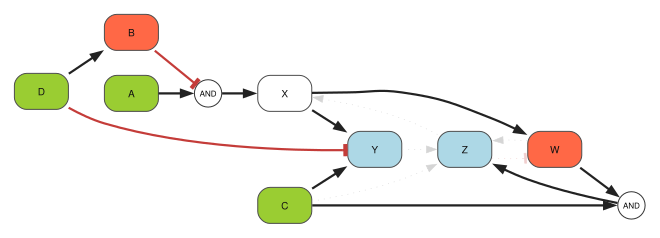

In [7]:
plot_cellnopt_model(method, show_unselected=True)

### Inspect the fitted signaling model

Hiding unselected reactions leaves the signaling hypothesis supported by this experiment. `D → B` controls the first AND gate, `X` branches toward `Y` and `W`, and the second AND gate combines `W` with `C` to activate `Z`. Separate routes can activate `Y` under different perturbations.

This is the shared pathway diagram. The next plots show how much of it is active in each condition.

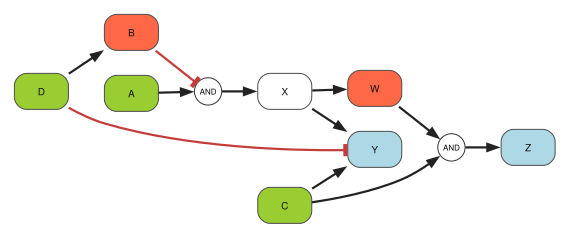

In [8]:
plot_cellnopt_model(method)

## Does the model reproduce the measured responses?

Each row is one intervention condition, and the `Y` and `Z` panels match the readout columns in the experiment table:

- red open circles show the measured endpoint response;
- blue squares show the model prediction;
- a vertical segment would show a disagreement;
- the background color summarizes the prediction error.

Only measured signaling responses are shown in this main fit view. Predicted activities of unmeasured internal proteins are inspected later, where they are clearly distinguished from experimental observations.

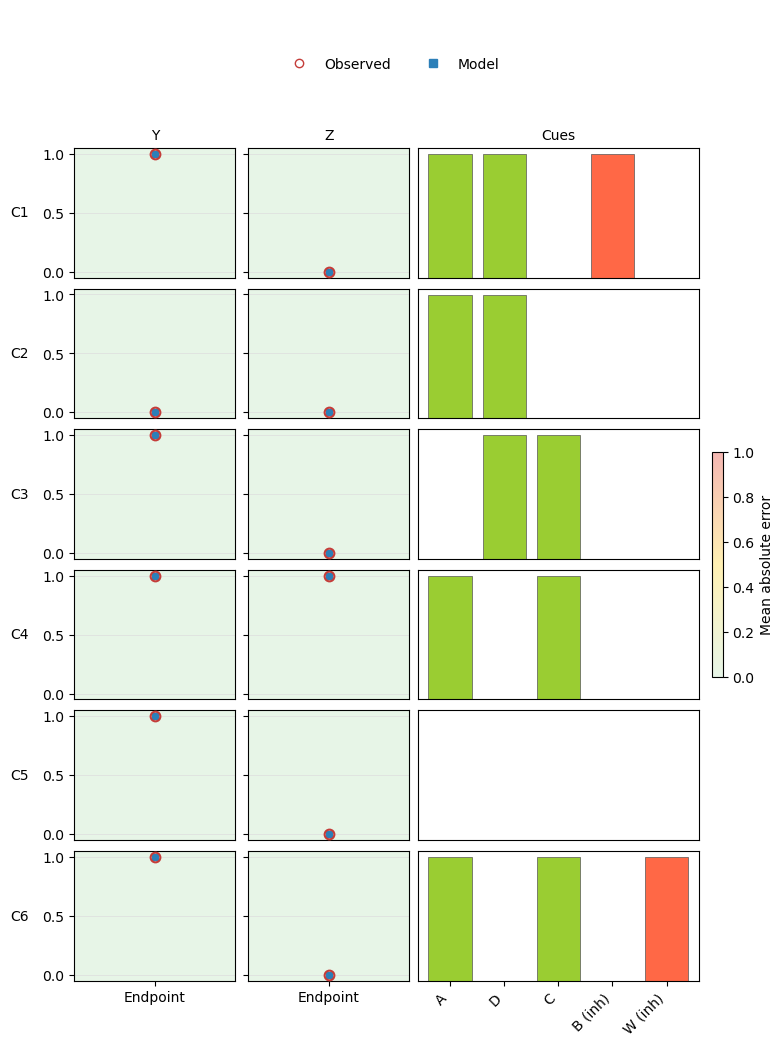

In [9]:
fit_figure, fit_axes = plot_cellnopt_fit(method)

The horizontal position is labelled **Endpoint** because these data contain one post-intervention snapshot, not a time course. The plot does not create an artificial starting value or assume that the first condition is a baseline. If future formulations model several measured time points, observed and predicted values can instead be placed at their actual sampling times.

## A pathway reaction can be present but inactive

It helps to separate the **pathway map** from the **response in one experiment**. A road can be present on a map even when no traffic uses it; likewise, a reaction can belong to the fitted signaling model even when its upstream requirements are not satisfied in one condition.

`C1` and `C2` have the same upstream inputs: `A=1`, `C=0`, and `D=1`. In both conditions, `D` can activate `B`. In `C1`, however, the experimental inhibitor forces `B` off. This allows the rule `A AND NOT B → X` to transmit the signal. In `C2`, `B` remains active, the `NOT B` requirement fails, and the same pathway branch is inactive and drawn with dashed lines.

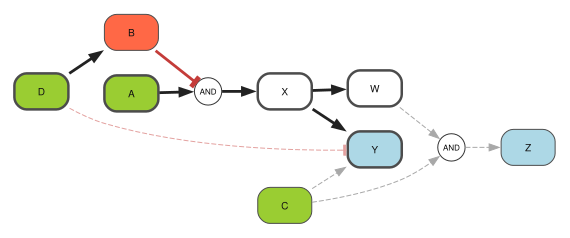

In [10]:
plot_cellnopt_model(method, condition="C1")

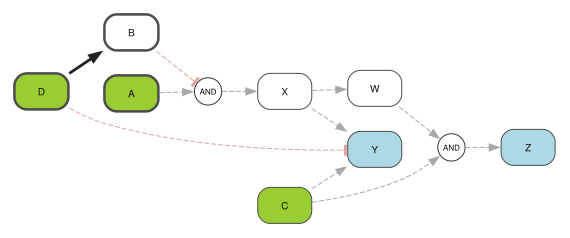

In [11]:
plot_cellnopt_model(method, condition="C2")

### An inhibitor changes its target, not the whole cell

`C4` and `C6` have the same upstream inputs. Without the inhibitor in `C4`, `X` activates `W`, the rule `W AND C → Z` is satisfied, and both readouts are active.

In `C6`, the inhibitor specifically forces internal protein `W` off. Signaling to `Y` remains active through `X` and `C`, but the AND rule producing `Z` is no longer satisfied, matching the observed `Y=1, Z=0`. The intervention therefore blocks one branch rather than being interpreted as a shutdown of the whole pathway.

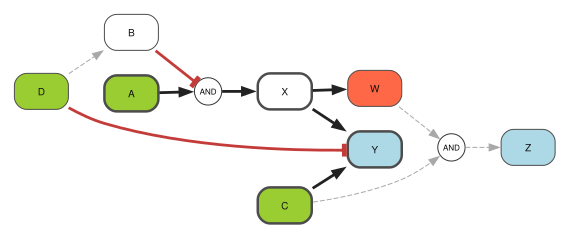

In [12]:
plot_cellnopt_model(method, condition="C6")

## A compact view for larger signaling experiments

When an experiment contains many perturbations or readouts, aligned heatmaps are easier to scan than one panel per response. Observed activities, predicted activities, absolute errors, and experimental cues remain aligned by condition. Unmeasured entries stay blank rather than being treated as zeros.

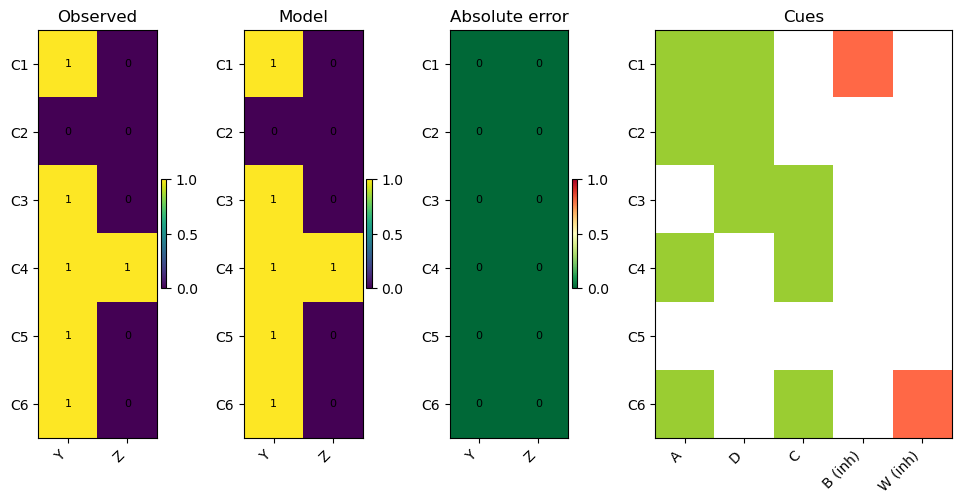

In [13]:
heatmap_figure, heatmap_axes = plot_cellnopt_fit(method, view="heatmap")

## Under the hood

The biological workflow above rests on a few modeling assumptions. This section states only the assumptions needed to interpret the result and separates the CellNOpt core from the acyclicity and connectivity requirements added by CORNETO.

### Endpoint Boolean assumptions

One reaction set is selected for the whole experiment, while protein and reaction activities are predicted separately for each condition.

For every condition:

- a selected reaction is active only when all its positive inputs are active and all its negative inputs are inactive;
- several active reactions producing the same protein act as OR alternatives;
- a stimulus or inhibitor overrides the usual production rule by fixing its target on or off;
- internal activities are predictions at the measured endpoint, not simulated intermediate time steps.

CORNETO represents these rules with vectorized binary variables: $Y_r$ for shared reaction selection, $Z_{rc}$ for condition-specific reaction activity, and $X_{vc}$ for condition-specific protein activity. The implementation uses exact linear constraints for AND, OR, and negative literals, but those linearization details do not change the biological assumptions above.

### Fit and model size

The model prioritizes agreement with observed readouts and uses a smaller penalty to prefer compact signaling explanations:

$$
\min\; \sum_{(v,c)\,\mathrm{observed}} |X_{vc}-m_{vc}| + \lambda\sum_r Y_r.
$$

Only measured entries contribute to the first term. Unmeasured proteins are not treated as zero. The second term counts selected Boolean reactions, so an AND gate is penalized once rather than once per input leg.

### What CORNETO adds

| Modeling element | Role in this formulation |
|---|---|
| Shared reaction selection across conditions | CellNOpt core |
| Condition-specific Boolean AND, OR, and inhibitory logic | CellNOpt core |
| Readout mismatch plus a model-size penalty | CellNOpt core |
| Acyclic selected reaction dependencies | CORNETO endpoint restriction |
| One shared structural flow connecting interventions to readouts | CORNETO connectivity extension |

Acyclicity is imposed on the **selected model**, not on the PKN. CORNETO assigns an ordering level $h_v$ to every protein and requires each selected dependency $u\rightarrow v$ to point forward:

$$
Y_r=1 \;\Longrightarrow\; h_u < h_v
\qquad\text{for every dependency }u\rightarrow v\text{ in reaction }r.
$$

This makes the endpoint response evaluable from the experimental inputs without choosing an update order or allowing a selected feedback loop to support itself.

Connectivity is a separate requirement. CORNETO sends an artificial bookkeeping flow from controlled proteins, through every selected dependency, to measured readouts. Selected dependencies must carry positive flow, unselected dependencies carry none, and flow is conserved at internal proteins. The resulting flow is a structural certificate that the selected model contains no disconnected or dangling reactions.

### Inspecting the inferred states

The tables below contain only selected reactions and the internal or measured proteins needed to interpret the example. Reaction activity and protein activity vary by condition; neither table contains additional experimental measurements. `Y` and `Z` are observed readouts, whereas `B`, `X`, and `W` are model predictions.

In [14]:
condition_names = list(inputs)
selected_mask = selected.astype(bool)
reaction_activity = pd.DataFrame(
    np.rint(problem.expr.reaction_active.value).astype(int),
    index=reaction_labels,
    columns=condition_names,
).loc[selected_mask]
species_states = pd.DataFrame(
    np.rint(problem.expr.vertex_value.value).astype(int),
    index=method.processed_graph.V,
    columns=condition_names,
).loc[["B", "X", "W", "Y", "Z"]]

display(reaction_activity, species_states)

,C1,C2,C3,C4,C5,C6
D -> B,1,1,1,0,0,0
X -> Y,1,0,0,1,0,1
X -> W,1,0,0,1,0,1
C -> Y,0,0,1,1,0,1
NOT D -> Y,0,0,0,1,1,1
A AND NOT B -> X,1,0,0,1,0,1
W AND C -> Z,0,0,0,1,0,0


,C1,C2,C3,C4,C5,C6
B,0,1,1,0,0,0
X,1,0,0,1,0,1
W,1,0,0,1,0,0
Y,1,0,1,1,1,1
Z,0,0,0,1,0,0


### Structural connectivity diagnostic

The following plot visualizes the artificial structural flow by edge width. It is useful for checking that selected reactions are connected to experimental inputs and measured outputs, and for finding an incorrectly mapped, disconnected, or dangling reaction.

This is a debugging view. Flow is shared across all conditions and records neither whether a reaction is active in one condition nor how strongly a biochemical signal passes through it.

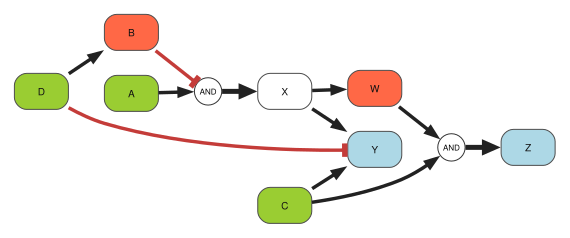

In [15]:
plot_cellnopt_model(method, width_by="flow")

All selected dependency legs happen to carry structural flow `1` in this solution, so they receive the same width. That equality does **not** mean the reactions have equal biological strength or importance. It only means that this particular bookkeeping flow can certify every selected dependency with the minimum required amount.

Structural-flow values are generally non-unique and solver-dependent; a different feasible certificate can assign different widths without changing the selected signaling model. The values are unrelated to protein activity, signal strength, reaction rate, confidence, or causal importance. Use the plot only to verify selected-model connectivity.

## Biological interpretation and limitations

This method is designed for intracellular signaling experiments in which cells are stimulated or inhibited and measured once at a chosen endpoint. The result is one compact pathway structure whose predicted activity changes across intervention conditions.

The fitted model answers the question posed at the beginning: it is a connected feed-forward signaling logic sufficient to explain these observed snapshots. “Sufficient” does not mean unique, dynamically complete, or necessarily identical to the pathway operating in the cell.

Feedback remains biologically plausible. A snapshot with both `Y` and `Z` active usually cannot reveal whether `Y` activated `Z`, `Z` activated `Y`, an upstream protein activated both, or a loop maintained them. The acyclic restriction therefore reflects what this experiment can identify; it is not evidence that the biological network contains no feedback. Feedback candidates remain visible in the PKN as hypotheses that were available but not established by this endpoint analysis.

A dynamic model is more appropriate when measurements cover activation and relaxation over time, proteins inside a proposed loop are directly perturbed, or the data show adaptation, oscillation, or dependence on initial state. Such analyses must state how time and updates are represented.

Other limitations remain: Boolean states simplify graded and stochastic signaling; inference is restricted to the supplied PKN; alternative models may fit equally well; and unmeasured internal activities remain predictions. Structural flow certifies connectivity only—it does not quantify signaling strength.

## Connection to causal structure learning

For readers coming from mathematics or causal inference, `CellNOptDAG` can be viewed as **interventional Boolean causal structure learning over a restricted hypothesis space**.

The variables are the binary protein activities $X_v$. The PKN acts as a causal *superstructure*: it specifies the allowed variables, directions, signs, and multi-input clauses. The optimization does not invent interactions outside that superstructure. Instead, it chooses which candidate reactions are needed to explain all intervention conditions.

Let $Y_r$ indicate whether candidate reaction $r$ is selected. If $P_r$ and $N_r$ are its positive and negative inputs, its condition-specific truth value is

$$
Z_{rc}=Y_r\land\bigwedge_{u\in P_r}X_{uc}\land\bigwedge_{w\in N_r}\neg X_{wc}.
$$

For a protein that is not experimentally fixed, alternative selected reactions producing that protein act as OR alternatives:

$$
X_{vc}=\bigvee_{r:\,\operatorname{product}(r)=v} Z_{rc}.
$$

The inferred equation for each protein is therefore a signed Boolean expression in disjunctive normal form. For example, selecting `A AND NOT B → X` and `C → X` gives

$$
X=(A\land\neg B)\lor C.
$$

The selection variables $Y_r$ are shared across conditions: this is the assumption that the underlying causal mechanisms remain invariant throughout the experiment. The state variables $X_{vc}$ and reaction activities $Z_{rc}$ vary because each condition applies different experimental manipulations.

A stimulus or inhibitor overrides the usual equation for its target and fixes that variable to `1` or `0`. In structural-causal notation, this plays the role of a hard intervention such as $\operatorname{do}(X_v=1)$ or $\operatorname{do}(X_v=0)$. CellNOptDAG then searches for a shared model that predicts the measured outcomes of these interventions:

$$
\min_Y\;\sum_{(v,c)\,\mathrm{observed}}|X_{vc}-m_{vc}|+\lambda\sum_rY_r.
$$

The first term is interventional prediction error and the second is a sparsity penalty on structural mechanisms. Because CORNETO also requires the selected dependencies to be acyclic, the fitted equations form a recursive Boolean structural causal model with a well-defined evaluation order.

| CellNOpt term | Causal or mathematical interpretation |
|---|---|
| Protein activity | Binary endogenous variable |
| PKN | Causal superstructure or hypothesis space |
| Selected reaction | Selected structural mechanism or Boolean clause |
| Stimulus or inhibitor | Hard intervention |
| Shared reaction selection | Invariant causal structure |
| Readout mismatch | Interventional prediction loss |
| Model-size penalty | Sparsity regularization |
| Acyclicity | Recursive structural causal model |
| Structural flow | Connectivity certificate, not a causal-effect estimate |

The phrase **causal discovery** needs one qualification here. This is not unrestricted discovery of a causal graph from data alone: the PKN already supplies the possible mechanisms, including the available AND clauses. The method selects among those mechanisms, while OR relationships arise from selecting several reactions with the same product. It is therefore more precise to call the task **PKN-constrained interventional Boolean causal structure learning**.

As in other causal-learning problems, the fitted structure need not be identifiable. Two candidate subnetworks may make exactly the same predictions under the available interventions. The size penalty can prefer a compact representative, but it cannot turn experimentally indistinguishable models into a uniquely established causal explanation.